In [ ]:
# ============================================================
# COMPLETE PIPELINE - SAIC INEGI Censos Económicos
# Proyecto: Nearshoring B2B Opportunity Mexico
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Montar Google Drive solo si es necesario
# ------------------------------------------------------------

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Rutas del proyecto
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

# Buscar automáticamente SAIC_INEGI.csv dentro del proyecto
possible_files = glob.glob(
    f"{PROJECT_DIR}/**/SAIC_INEGI.csv",
    recursive=True
)

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No encontré SAIC_INEGI.csv dentro de Nearshoring_Project. "
        "Verifica que esté en Mi unidad/Nearshoring_Project/Inegi_data/"
    )

file_path = possible_files[0]

print("Archivo usado:")
print(file_path)

print("\nTamaño del archivo:")
print(f"{os.path.getsize(file_path) / (1024 * 1024):,.2f} MB")

# ------------------------------------------------------------
# 2. Detectar automáticamente la fila de encabezados reales
# ------------------------------------------------------------

preview = pd.read_csv(
    file_path,
    encoding="utf-8",
    sep=",",
    header=None,
    nrows=30,
    low_memory=False
)

header_row = None

for idx in preview.index:
    row_values = preview.loc[idx].astype(str).str.strip().tolist()
    row_text = " | ".join(row_values).lower()

    if ("año censal" in row_text or "ano censal" in row_text) and "entidad" in row_text:
        header_row = idx
        break

if header_row is None:
    raise ValueError(
        "No pude detectar la fila de encabezados. "
        "Busca manualmente en las primeras filas dónde aparece 'Año Censal'."
    )

print(f"\nFila de encabezados detectada: {header_row}")

raw_headers = preview.loc[header_row].tolist()

headers = []
for i, h in enumerate(raw_headers):
    if pd.isna(h) or str(h).strip() == "":
        headers.append(f"empty_col_{i}")
    else:
        headers.append(str(h).strip())

print("\nEncabezados detectados:")
for i, col in enumerate(headers, start=1):
    print(i, col)

# ------------------------------------------------------------
# 3. Leer la base completa
# ------------------------------------------------------------

df_raw = pd.read_csv(
    file_path,
    encoding="utf-8",
    sep=",",
    header=None,
    skiprows=header_row + 1,
    names=headers,
    low_memory=False
)

df_raw = df_raw.dropna(axis=1, how="all")
df_raw = df_raw.dropna(axis=0, how="all")

print("\nDimensiones después de leer correctamente:")
print(df_raw.shape)

# ------------------------------------------------------------
# 4. Limpiar nombres de columnas
# ------------------------------------------------------------

def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace("á", "a")
    col = col.replace("é", "e")
    col = col.replace("í", "i")
    col = col.replace("ó", "o")
    col = col.replace("ú", "u")
    col = col.replace("ñ", "n")
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"[^a-z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col

df = df_raw.copy()
df.columns = [clean_column_name(c) for c in df.columns]

print("\nColumnas limpias:")
for i, col in enumerate(df.columns, start=1):
    print(i, col)

# ------------------------------------------------------------
# 5. Renombrar columnas centrales
# ------------------------------------------------------------

required_cols = {
    "ano_censal": "year",
    "entidad": "entidad_raw",
    "municipio": "municipio_raw",
    "actividad_economica": "activity_raw",
    "ue_unidades_economicas": "establishments",
    "h001a_personal_ocupado_total": "employment",
    "a131a_valor_agregado_censal_bruto_millones_de_pesos": "value_added",
    "a800a_total_de_ingresos_millones_de_pesos": "total_income",
    "a700a_total_de_gastos_millones_de_pesos": "total_expenses",
    "a211a_inversion_total_millones_de_pesos": "investment",
    "a221a_formacion_bruta_de_capital_fijo_millones_de_pesos": "gross_fixed_capital_formation"
}

missing_cols = [col for col in required_cols.keys() if col not in df.columns]

if missing_cols:
    print("\nColumnas faltantes:")
    for col in missing_cols:
        print("-", col)
    raise KeyError("Faltan columnas necesarias. Revisa los nombres impresos arriba.")

df = df.rename(columns=required_cols)

print("\nColumnas centrales renombradas:")
for old, new in required_cols.items():
    print(f"{old} --> {new}")

# ------------------------------------------------------------
# 6. Funciones auxiliares
# ------------------------------------------------------------

def extract_geo_code(text):
    if pd.isna(text):
        return np.nan

    text = str(text).strip()
    match = re.match(r"^(\d{1,3})\b", text)

    if match:
        return match.group(1)

    return np.nan


def remove_geo_code(text):
    if pd.isna(text):
        return np.nan

    text = str(text).strip()
    text = re.sub(r"^\d{1,3}\s+", "", text)

    return text.strip()


def extract_scian_code(text):
    if pd.isna(text):
        return np.nan

    text = str(text).strip()

    match_range = re.search(r"\b(\d{2}-\d{2})\b", text)
    if match_range:
        return match_range.group(1)

    match_digits = re.search(r"\b(\d{2,6})\b", text)
    if match_digits:
        return match_digits.group(1)

    return np.nan


def remove_scian_code(text):
    if pd.isna(text):
        return np.nan

    text = str(text).strip()
    text = re.sub(r"^(sector|subsector|rama|subrama|clase)\s+", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^\d{2}-\d{2}\s+", "", text)
    text = re.sub(r"^\d{2,6}\s+", "", text)

    return text.strip()


def detect_scian_level(activity):
    if pd.isna(activity):
        return np.nan

    activity_lower = str(activity).lower().strip()

    if "total nacional" in activity_lower:
        return "total_nacional"
    elif activity_lower.startswith("sector"):
        return "sector"
    elif activity_lower.startswith("subsector"):
        return "subsector"
    elif activity_lower.startswith("rama"):
        return "rama"
    elif activity_lower.startswith("subrama"):
        return "subrama"
    elif activity_lower.startswith("clase"):
        return "clase"
    else:
        return "unknown"


def safe_divide(num, den):
    return np.where(
        (pd.notna(den)) & (den != 0),
        num / den,
        np.nan
    )

# ------------------------------------------------------------
# 7. Construir claves geográficas y SCIAN
# ------------------------------------------------------------

df["entidad_id"] = df["entidad_raw"].apply(extract_geo_code)
df["entidad_name"] = df["entidad_raw"].apply(remove_geo_code)

df["municipio_id"] = df["municipio_raw"].apply(extract_geo_code)
df["municipio_name"] = df["municipio_raw"].apply(remove_geo_code)

df["scian_code"] = df["activity_raw"].apply(extract_scian_code)
df["scian_description"] = df["activity_raw"].apply(remove_scian_code)
df["scian_level"] = df["activity_raw"].apply(detect_scian_level)

df["entidad_id"] = df["entidad_id"].astype("string").str.zfill(2)
df["municipio_id"] = df["municipio_id"].astype("string").str.zfill(3)

df["geo_key"] = np.where(
    df["entidad_id"].notna() & df["municipio_id"].notna(),
    df["entidad_id"] + df["municipio_id"],
    np.nan
)

# ------------------------------------------------------------
# 8. Convertir columnas numéricas
# ------------------------------------------------------------

numeric_cols = [
    "establishments",
    "employment",
    "value_added",
    "total_income",
    "total_expenses",
    "investment",
    "gross_fixed_capital_formation"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({"nan": np.nan, "NaN": np.nan, "": np.nan, "None": np.nan})
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# 9. Filtrar municipios y manufactura
# ------------------------------------------------------------

df_muni = df[df["municipio_raw"].notna()].copy()

df_muni["is_manufacturing"] = (
    df_muni["scian_code"].astype(str).str.startswith(("31", "32", "33")) |
    (df_muni["scian_code"].astype(str) == "31-33")
)

df_mfg = df_muni[df_muni["is_manufacturing"]].copy()

print("\nDimensiones de base municipal manufacturera:")
print(df_mfg.shape)

print("\nDistribución por nivel SCIAN:")
print(df_mfg["scian_level"].value_counts(dropna=False))

print("\nAños disponibles:")
print(sorted(df_mfg["year"].astype(str).dropna().unique()))

print("\nNúmero de entidades:")
print(df_mfg["entidad_id"].nunique())

print("\nNúmero de municipios:")
print(df_mfg["geo_key"].nunique())

# ------------------------------------------------------------
# 10. Indicadores derivados
# ------------------------------------------------------------

df_mfg["avg_employment_per_establishment"] = safe_divide(
    df_mfg["employment"],
    df_mfg["establishments"]
)

df_mfg["value_added_per_worker"] = safe_divide(
    df_mfg["value_added"],
    df_mfg["employment"]
)

df_mfg["income_per_worker"] = safe_divide(
    df_mfg["total_income"],
    df_mfg["employment"]
)

df_mfg["investment_per_worker"] = safe_divide(
    df_mfg["investment"],
    df_mfg["employment"]
)

# ------------------------------------------------------------
# 11. Crear municipality_industrial_base
# ------------------------------------------------------------

base_cols = [
    "year",
    "entidad_id",
    "entidad_name",
    "municipio_id",
    "municipio_name",
    "geo_key",
    "scian_code",
    "scian_description",
    "scian_level",
    "establishments",
    "employment",
    "value_added",
    "total_income",
    "total_expenses",
    "investment",
    "gross_fixed_capital_formation",
    "avg_employment_per_establishment",
    "value_added_per_worker",
    "income_per_worker",
    "investment_per_worker"
]

municipality_industrial_base = df_mfg[base_cols].copy()

# ------------------------------------------------------------
# 12. Crear municipality_industrial_summary sin doble conteo
# ------------------------------------------------------------

summary_source = municipality_industrial_base[
    municipality_industrial_base["scian_code"] == "31-33"
].copy()

summary_cols = [
    "year",
    "entidad_id",
    "entidad_name",
    "municipio_id",
    "municipio_name",
    "geo_key",
    "establishments",
    "employment",
    "value_added",
    "total_income",
    "total_expenses",
    "investment",
    "gross_fixed_capital_formation"
]

municipality_industrial_summary = summary_source[summary_cols].copy()

municipality_industrial_summary = municipality_industrial_summary.rename(columns={
    "establishments": "total_manufacturing_establishments",
    "employment": "total_manufacturing_employment",
    "value_added": "total_manufacturing_value_added",
    "total_income": "total_manufacturing_income",
    "total_expenses": "total_manufacturing_expenses",
    "investment": "total_manufacturing_investment",
    "gross_fixed_capital_formation": "total_manufacturing_gross_fixed_capital_formation"
})

municipality_industrial_summary["avg_manufacturing_employment_per_establishment"] = safe_divide(
    municipality_industrial_summary["total_manufacturing_employment"],
    municipality_industrial_summary["total_manufacturing_establishments"]
)

municipality_industrial_summary["manufacturing_value_added_per_worker"] = safe_divide(
    municipality_industrial_summary["total_manufacturing_value_added"],
    municipality_industrial_summary["total_manufacturing_employment"]
)

municipality_industrial_summary["manufacturing_income_per_worker"] = safe_divide(
    municipality_industrial_summary["total_manufacturing_income"],
    municipality_industrial_summary["total_manufacturing_employment"]
)

activity_count_source = municipality_industrial_base[
    municipality_industrial_base["scian_level"].isin(["subsector", "rama", "subrama", "clase"])
].copy()

activity_count = (
    activity_count_source
    .groupby(["year", "geo_key"], as_index=False)
    .agg(number_of_manufacturing_scian_activities=("scian_code", "nunique"))
)

municipality_industrial_summary = municipality_industrial_summary.merge(
    activity_count,
    on=["year", "geo_key"],
    how="left"
)

# ------------------------------------------------------------
# 13. Guardar CSV procesados
# ------------------------------------------------------------

base_output = f"{PROCESSED_DIR}/municipality_industrial_base.csv"
summary_output = f"{PROCESSED_DIR}/municipality_industrial_summary.csv"

municipality_industrial_base.to_csv(
    base_output,
    index=False,
    encoding="utf-8-sig"
)

municipality_industrial_summary.to_csv(
    summary_output,
    index=False,
    encoding="utf-8-sig"
)

print("\nArchivo guardado:")
print(base_output)
print("Dimensiones:", municipality_industrial_base.shape)

print("\nArchivo guardado:")
print(summary_output)
print("Dimensiones:", municipality_industrial_summary.shape)

# ------------------------------------------------------------
# 14. Crear validation_report.csv
# ------------------------------------------------------------

validation_items = [
    {
        "check": "rows_municipality_industrial_base",
        "result": municipality_industrial_base.shape[0]
    },
    {
        "check": "columns_municipality_industrial_base",
        "result": municipality_industrial_base.shape[1]
    },
    {
        "check": "rows_municipality_industrial_summary",
        "result": municipality_industrial_summary.shape[0]
    },
    {
        "check": "columns_municipality_industrial_summary",
        "result": municipality_industrial_summary.shape[1]
    },
    {
        "check": "years_available",
        "result": ", ".join(sorted(municipality_industrial_base["year"].astype(str).unique()))
    },
    {
        "check": "number_of_entities",
        "result": municipality_industrial_base["entidad_id"].nunique()
    },
    {
        "check": "number_of_municipalities",
        "result": municipality_industrial_base["geo_key"].nunique()
    },
    {
        "check": "employment_variable_used",
        "result": "H001A Personal ocupado total"
    },
    {
        "check": "summary_level_used",
        "result": "Sector 31-33 Industrias manufactureras"
    },
    {
        "check": "double_counting_avoided",
        "result": True
    },
    {
        "check": "scian_levels_available",
        "result": ", ".join(sorted(municipality_industrial_base["scian_level"].dropna().unique()))
    }
]

validation_report = pd.DataFrame(validation_items)

validation_output = f"{PROCESSED_DIR}/validation_report.csv"

validation_report.to_csv(
    validation_output,
    index=False,
    encoding="utf-8-sig"
)

print("\nArchivo guardado:")
print(validation_output)

display(validation_report)

# ------------------------------------------------------------
# 15. Vista rápida
# ------------------------------------------------------------

print("\nPrimeras filas de municipality_industrial_summary:")
display(municipality_industrial_summary.head(10))

Google Drive ya está montado.
Archivo usado:
/content/drive/MyDrive/Nearshoring_Project/Inegi_data/SAIC_INEGI.csv

Tamaño del archivo:
64.75 MB

Fila de encabezados detectada: 4

Encabezados detectados:
1 Año Censal
2 Entidad
3 Municipio
4 Actividad económica
5 UE Unidades económicas
6 Q000C Compra y adquisición de activos fijos y reformas mayores (millones de pesos)
7 Q000D Ventas totales de activos fijos (millones de pesos)
8 P000A Total de inventario inicial (millones de pesos)
9 P000B Total de inventario final (millones de pesos)
10 O010A Valor de productos elaborados, generados y extraídos (millones de pesos)
11 O020A Activos fijos producidos para uso propio (millones de pesos)
12 M700A Ingresos por maquilar o transformar materias primas propiedad de terceros (millones de pesos)
13 P030C Variación de inventarios de productos en proceso (millones de pesos)
14 A511A Margen por reventa de mercancías (millones de pesos)
15 M020A Ingresos por prestación de servicios profesionales, cien

,check,result
0,rows_municipality_industrial_base,111489
1,columns_municipality_industrial_base,20
2,rows_municipality_industrial_summary,12038
3,columns_municipality_industrial_summary,17
4,years_available,"2003, 2008, 2013, 2018, 2023"
5,number_of_entities,32
6,number_of_municipalities,2474
7,employment_variable_used,H001A Personal ocupado total
8,summary_level_used,Sector 31-33 Industrias manufactureras
9,double_counting_avoided,True



Primeras filas de municipality_industrial_summary:


,year,entidad_id,entidad_name,municipio_id,municipio_name,geo_key,total_manufacturing_establishments,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_income,total_manufacturing_expenses,total_manufacturing_investment,total_manufacturing_gross_fixed_capital_formation,avg_manufacturing_employment_per_establishment,manufacturing_value_added_per_worker,manufacturing_income_per_worker,number_of_manufacturing_scian_activities
0,2023,01,Aguascalientes,001,Aguascalientes,01001,4166.0,75556.0,128718.721,282738.029,154754.157,14427.192,14112.170,18.136342,1.703620,3.742099,21
1,2023,01,Aguascalientes,002,Asientos,01002,109.0,365.0,56.486,107.353,50.540,0.894,0.707,3.348624,0.154756,0.294118,11
2,2023,01,Aguascalientes,003,Calvillo,01003,253.0,3201.0,636.409,1469.603,856.290,2.593,4.731,12.652174,0.198816,0.459107,14
3,2023,01,Aguascalientes,004,Cosío,01004,45.0,1677.0,351.261,456.254,125.554,13.127,13.163,37.266667,0.209458,0.272066,10
4,2023,01,Aguascalientes,005,Jesús María,01005,817.0,43859.0,22767.628,50970.745,28078.762,261.598,323.641,53.682987,0.519110,1.162150,21
5,2023,01,Aguascalientes,006,Pabellón de Arteaga,01006,164.0,727.0,188.423,439.146,253.977,-4.520,4.251,4.432927,0.259179,0.604052,13
6,2023,01,Aguascalientes,007,Rincón de Romos,01007,226.0,2767.0,1601.445,4765.968,3045.935,83.779,46.050,12.243363,0.578766,1.722432,16
7,2023,01,Aguascalientes,008,San José de Gracia,01008,63.0,239.0,22.021,46.704,24.752,0.086,0.063,3.793651,0.092138,0.195414,11
8,2023,01,Aguascalientes,009,Tepezalá,01009,57.0,649.0,2714.070,7038.032,4431.455,154.005,89.040,11.385965,4.181926,10.844425,11
9,2023,01,Aguascalientes,010,El Llano,01010,53.0,777.0,280.638,1268.703,1010.370,-8.478,2.146,14.660377,0.361181,1.632822,13


In [1]:
# ============================================================
# Create_industrial_capacity_panel.py
# Project: Nearshoring B2B Opportunity Mexico
# Goal: Create municipality-year industrial capacity panel
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Mount Google Drive if needed
# ------------------------------------------------------------

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Define project paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

# Search for municipality_industrial_summary.csv inside the project
possible_files = glob.glob(
    f"{PROJECT_DIR}/**/municipality_industrial_summary.csv",
    recursive=True
)

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No encontré municipality_industrial_summary.csv dentro de Nearshoring_Project."
    )

input_path = possible_files[0]
output_path = f"{PROCESSED_DIR}/municipality_industrial_capacity_panel.csv"

print("Archivo usado:")
print(input_path)

# ------------------------------------------------------------
# 2. Load municipality industrial summary
# ------------------------------------------------------------

summary = pd.read_csv(
    input_path,
    dtype={
        "year": str,
        "entidad_id": str,
        "municipio_id": str,
        "geo_key": str
    }
)

print("\nBase cargada:")
print(summary.shape)

print("\nAños disponibles:")
print(sorted(summary["year"].dropna().unique()))

# ------------------------------------------------------------
# 3. Select relevant columns
# ------------------------------------------------------------

required_cols = [
    "year",
    "entidad_id",
    "entidad_name",
    "municipio_id",
    "municipio_name",
    "geo_key",
    "total_manufacturing_establishments",
    "total_manufacturing_employment",
    "total_manufacturing_value_added",
    "total_manufacturing_income",
    "total_manufacturing_expenses",
    "total_manufacturing_investment",
    "total_manufacturing_gross_fixed_capital_formation",
    "avg_manufacturing_employment_per_establishment",
    "manufacturing_value_added_per_worker",
    "manufacturing_income_per_worker",
    "number_of_manufacturing_scian_activities"
]

missing_cols = [col for col in required_cols if col not in summary.columns]

if missing_cols:
    print("Columnas faltantes:")
    for col in missing_cols:
        print("-", col)
    raise KeyError("Faltan columnas necesarias para construir el panel.")

panel = summary[required_cols].copy()

# ------------------------------------------------------------
# 4. Convert numeric columns
# ------------------------------------------------------------

numeric_cols = [
    "total_manufacturing_establishments",
    "total_manufacturing_employment",
    "total_manufacturing_value_added",
    "total_manufacturing_income",
    "total_manufacturing_expenses",
    "total_manufacturing_investment",
    "total_manufacturing_gross_fixed_capital_formation",
    "avg_manufacturing_employment_per_establishment",
    "manufacturing_value_added_per_worker",
    "manufacturing_income_per_worker",
    "number_of_manufacturing_scian_activities"
]

for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

# ------------------------------------------------------------
# 5. Define variables used in the initial score
# ------------------------------------------------------------
# This is an initial industrial capacity score, not a nearshoring score.
#
# Variables:
# - employment: manufacturing labor scale
# - value added: economic relevance
# - income: operational/economic scale
# - establishments: business presence
# - diversity: number of manufacturing SCIAN activities
# - average size: average workers per establishment
# - value added per worker: apparent productivity

score_components = {
    "score_employment_within_year": "total_manufacturing_employment",
    "score_value_added_within_year": "total_manufacturing_value_added",
    "score_income_within_year": "total_manufacturing_income",
    "score_establishments_within_year": "total_manufacturing_establishments",
    "score_industrial_diversity_within_year": "number_of_manufacturing_scian_activities",
    "score_avg_size_within_year": "avg_manufacturing_employment_per_establishment",
    "score_value_added_per_worker_within_year": "manufacturing_value_added_per_worker"
}

# ------------------------------------------------------------
# 6. Create percentile scores within each year
# ------------------------------------------------------------
# Interpretation:
# score_x_within_year = relative position of the municipality
# in that variable compared with all municipalities in the same year.
#
# Important:
# These component scores are percentiles.
# The composite industrial_capacity_score is not directly interpreted
# as a percentile until we compute industrial_capacity_percentile.

for score_col, source_col in score_components.items():
    panel[score_col] = (
        panel
        .groupby("year")[source_col]
        .transform(lambda s: s.rank(pct=True, ascending=True, method="average"))
    )

# ------------------------------------------------------------
# 7. Create component rankings within each year
# ------------------------------------------------------------
# Rank 1 = highest value in that variable within that year.

rank_components = {
    "rank_employment_within_year": "total_manufacturing_employment",
    "rank_value_added_within_year": "total_manufacturing_value_added",
    "rank_income_within_year": "total_manufacturing_income",
    "rank_establishments_within_year": "total_manufacturing_establishments",
    "rank_industrial_diversity_within_year": "number_of_manufacturing_scian_activities",
    "rank_avg_size_within_year": "avg_manufacturing_employment_per_establishment",
    "rank_value_added_per_worker_within_year": "manufacturing_value_added_per_worker"
}

for rank_col, source_col in rank_components.items():
    panel[rank_col] = (
        panel
        .groupby("year")[source_col]
        .transform(lambda s: s.rank(ascending=False, method="min"))
    )

# ------------------------------------------------------------
# 8. Create initial industrial capacity score
# ------------------------------------------------------------
# Initial weights:
# - Employment: 25%
# - Value added: 25%
# - Income: 15%
# - Establishments: 15%
# - Industrial diversity: 10%
# - Average establishment size: 5%
# - Value added per worker: 5%
#
# Interpretation:
# This score summarizes weighted performance across normalized
# manufacturing capacity dimensions. It is not directly a percentile.

panel["industrial_capacity_score"] = (
    0.25 * panel["score_employment_within_year"] +
    0.25 * panel["score_value_added_within_year"] +
    0.15 * panel["score_income_within_year"] +
    0.15 * panel["score_establishments_within_year"] +
    0.10 * panel["score_industrial_diversity_within_year"] +
    0.05 * panel["score_avg_size_within_year"] +
    0.05 * panel["score_value_added_per_worker_within_year"]
)

# ------------------------------------------------------------
# 9. Create percentile and rank of the composite score
# ------------------------------------------------------------
# This is the key interpretation variable:
# industrial_capacity_percentile tells the municipality's relative
# position after ordering the final composite score within each year.

panel["industrial_capacity_percentile"] = (
    panel
    .groupby("year")["industrial_capacity_score"]
    .transform(lambda s: s.rank(pct=True, ascending=True, method="average"))
)

panel["rank_industrial_capacity_within_year"] = (
    panel
    .groupby("year")["industrial_capacity_score"]
    .transform(lambda s: s.rank(ascending=False, method="min"))
)

# ------------------------------------------------------------
# 10. Create relative interpretation groups
# ------------------------------------------------------------

def classify_industrial_capacity(percentile):
    if pd.isna(percentile):
        return np.nan
    elif percentile >= 0.95:
        return "Top industrial hub"
    elif percentile >= 0.90:
        return "Strong industrial municipality"
    elif percentile >= 0.75:
        return "Relevant industrial base"
    elif percentile >= 0.50:
        return "Moderate industrial base"
    else:
        return "Low industrial base"

panel["industrial_capacity_group"] = panel["industrial_capacity_percentile"].apply(
    classify_industrial_capacity
)

# ------------------------------------------------------------
# 11. Optional flags for easier filtering
# ------------------------------------------------------------

panel["is_top_5_percent_within_year"] = panel["industrial_capacity_percentile"] >= 0.95
panel["is_top_10_percent_within_year"] = panel["industrial_capacity_percentile"] >= 0.90
panel["is_top_25_percent_within_year"] = panel["industrial_capacity_percentile"] >= 0.75

# ------------------------------------------------------------
# 12. Reorder columns
# ------------------------------------------------------------

final_cols = [
    "year",
    "entidad_id",
    "entidad_name",
    "municipio_id",
    "municipio_name",
    "geo_key",

    "industrial_capacity_score",
    "industrial_capacity_percentile",
    "rank_industrial_capacity_within_year",
    "industrial_capacity_group",
    "is_top_5_percent_within_year",
    "is_top_10_percent_within_year",
    "is_top_25_percent_within_year",

    "total_manufacturing_establishments",
    "total_manufacturing_employment",
    "total_manufacturing_value_added",
    "total_manufacturing_income",
    "total_manufacturing_expenses",
    "total_manufacturing_investment",
    "total_manufacturing_gross_fixed_capital_formation",
    "avg_manufacturing_employment_per_establishment",
    "manufacturing_value_added_per_worker",
    "manufacturing_income_per_worker",
    "number_of_manufacturing_scian_activities",

    "score_employment_within_year",
    "score_value_added_within_year",
    "score_income_within_year",
    "score_establishments_within_year",
    "score_industrial_diversity_within_year",
    "score_avg_size_within_year",
    "score_value_added_per_worker_within_year",

    "rank_employment_within_year",
    "rank_value_added_within_year",
    "rank_income_within_year",
    "rank_establishments_within_year",
    "rank_industrial_diversity_within_year",
    "rank_avg_size_within_year",
    "rank_value_added_per_worker_within_year"
]

panel = panel[final_cols].copy()

# ------------------------------------------------------------
# 13. Sort and save
# ------------------------------------------------------------

panel = panel.sort_values(
    ["year", "rank_industrial_capacity_within_year"],
    ascending=[True, True]
).reset_index(drop=True)

panel.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nArchivo guardado:")
print(output_path)

print("\nDimensiones del panel:")
print(panel.shape)

# ------------------------------------------------------------
# 14. Quick validation
# ------------------------------------------------------------

print("\nAños en el panel:")
print(sorted(panel["year"].unique()))

print("\nNúmero de municipios por año:")
display(
    panel
    .groupby("year")["geo_key"]
    .nunique()
    .reset_index(name="number_of_municipalities")
)

print("\nDistribución de grupos por año:")
display(
    panel
    .groupby(["year", "industrial_capacity_group"])
    .size()
    .reset_index(name="municipalities")
)

print("\nTop 20 municipios por industrial_capacity_score en 2023:")
display(
    panel[panel["year"] == "2023"]
    .sort_values("rank_industrial_capacity_within_year")
    .head(20)
)



Mounted at /content/drive
Archivo usado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_summary.csv

Base cargada:
(12038, 17)

Años disponibles:
['2003', '2008', '2013', '2018', '2023']

Archivo guardado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_capacity_panel.csv

Dimensiones del panel:
(12038, 38)

Años en el panel:
['2003', '2008', '2013', '2018', '2023']

Número de municipios por año:


,year,number_of_municipalities
0,2003,2321
1,2008,2400
2,2013,2419
3,2018,2447
4,2023,2451



Distribución de grupos por año:


,year,industrial_capacity_group,municipalities
0,2003,Low industrial base,950
1,2003,Moderate industrial base,476
2,2003,Relevant industrial base,285
3,2003,Strong industrial municipality,95
4,2003,Top industrial hub,96
5,2008,Low industrial base,1030
6,2008,Moderate industrial base,516
7,2008,Relevant industrial base,309
8,2008,Strong industrial municipality,103
9,2008,Top industrial hub,104



Top 20 municipios por industrial_capacity_score en 2023:


,year,entidad_id,entidad_name,municipio_id,municipio_name,geo_key,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,...,score_industrial_diversity_within_year,score_avg_size_within_year,score_value_added_per_worker_within_year,rank_employment_within_year,rank_value_added_within_year,rank_income_within_year,rank_establishments_within_year,rank_industrial_diversity_within_year,rank_avg_size_within_year,rank_value_added_per_worker_within_year
9587,2023,05,Coahuila de Zaragoza,030,Saltillo,05030,0.992587,1.000000,1.0,Top industrial hub,...,0.988780,0.954486,0.993435,19.0,1.0,2.0,28.0,1.0,105.0,16.0
9588,2023,24,San Luis Potosí,028,San Luis Potosí,24028,0.991693,0.999562,2.0,Top industrial hub,...,0.988780,0.968490,0.945733,8.0,8.0,5.0,19.0,1.0,73.0,125.0
9589,2023,22,Querétaro,014,Querétaro,22014,0.991194,0.999125,3.0,Top industrial hub,...,0.988780,0.963676,0.953173,11.0,9.0,7.0,20.0,1.0,84.0,108.0
9590,2023,01,Aguascalientes,001,Aguascalientes,01001,0.990765,0.998687,4.0,Top industrial hub,...,0.988780,0.936105,0.978556,18.0,7.0,11.0,12.0,1.0,147.0,50.0
9591,2023,15,México,106,Toluca,15106,0.990511,0.998249,5.0,Top industrial hub,...,0.988780,0.939606,0.954486,13.0,11.0,6.0,6.0,1.0,139.0,105.0
9592,2023,02,Baja California,004,Tijuana,02004,0.990424,0.997812,6.0,Top industrial hub,...,0.988780,0.992560,0.875711,2.0,5.0,9.0,14.0,1.0,18.0,285.0
9593,2023,14,Jalisco,120,Zapopan,14120,0.989973,0.997374,7.0,Top industrial hub,...,0.988780,0.958425,0.934354,6.0,12.0,19.0,11.0,1.0,96.0,151.0
9594,2023,08,Chihuahua,037,Juárez,08037,0.989296,0.996937,8.0,Top industrial hub,...,0.988780,0.997374,0.868271,1.0,2.0,15.0,31.0,1.0,7.0,302.0
9595,2023,26,Sonora,030,Hermosillo,26030,0.988516,0.996499,9.0,Top industrial hub,...,0.988780,0.926039,0.975930,25.0,10.0,18.0,13.0,1.0,170.0,56.0
9596,2023,19,Nuevo León,006,Apodaca,19006,0.988226,0.996061,10.0,Top industrial hub,...,0.968992,0.994311,0.940481,4.0,6.0,3.0,73.0,57.0,14.0,137.0


Google Drive ya está montado.
Archivo usado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_capacity_panel.csv

Carpeta de salida para figuras:
/content/drive/MyDrive/Nearshoring_Project/outputs/figures

Base cargada:
(12038, 38)

Años disponibles:
['2003', '2008', '2013', '2018', '2023']

Base filtrada para 2023:
(2451, 38)
Figura guardada en: /content/drive/MyDrive/Nearshoring_Project/outputs/figures/top20_industrial_capacity_score_2023.png


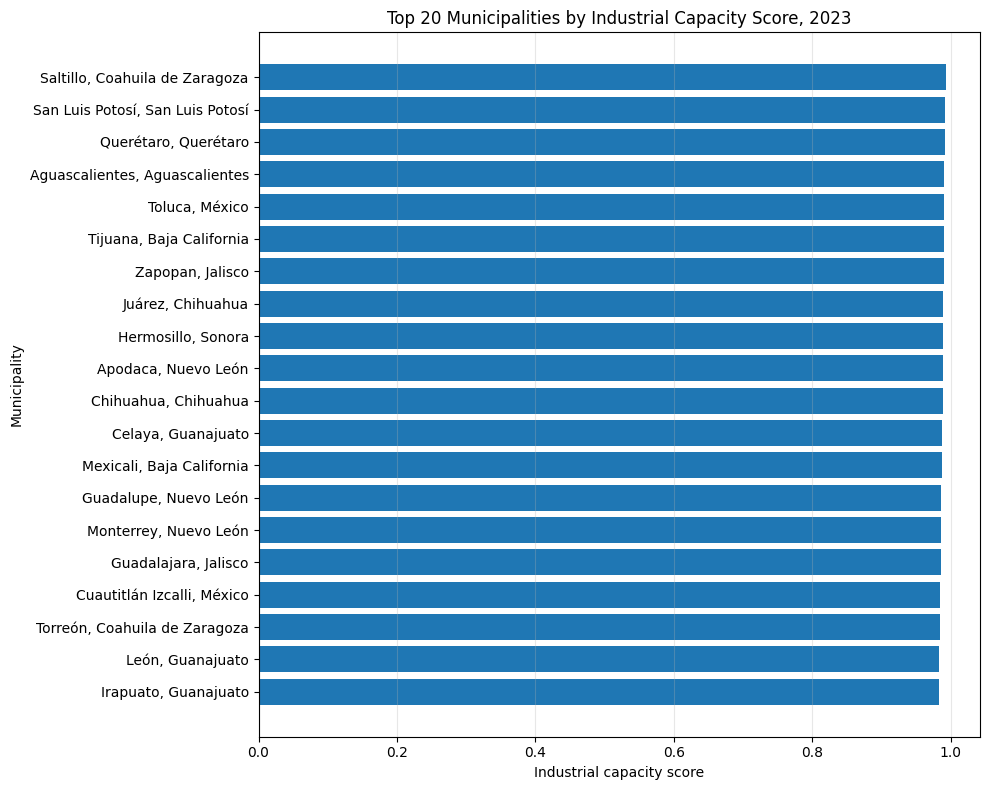

Figura guardada en: /content/drive/MyDrive/Nearshoring_Project/outputs/figures/top20_manufacturing_employment_2023.png


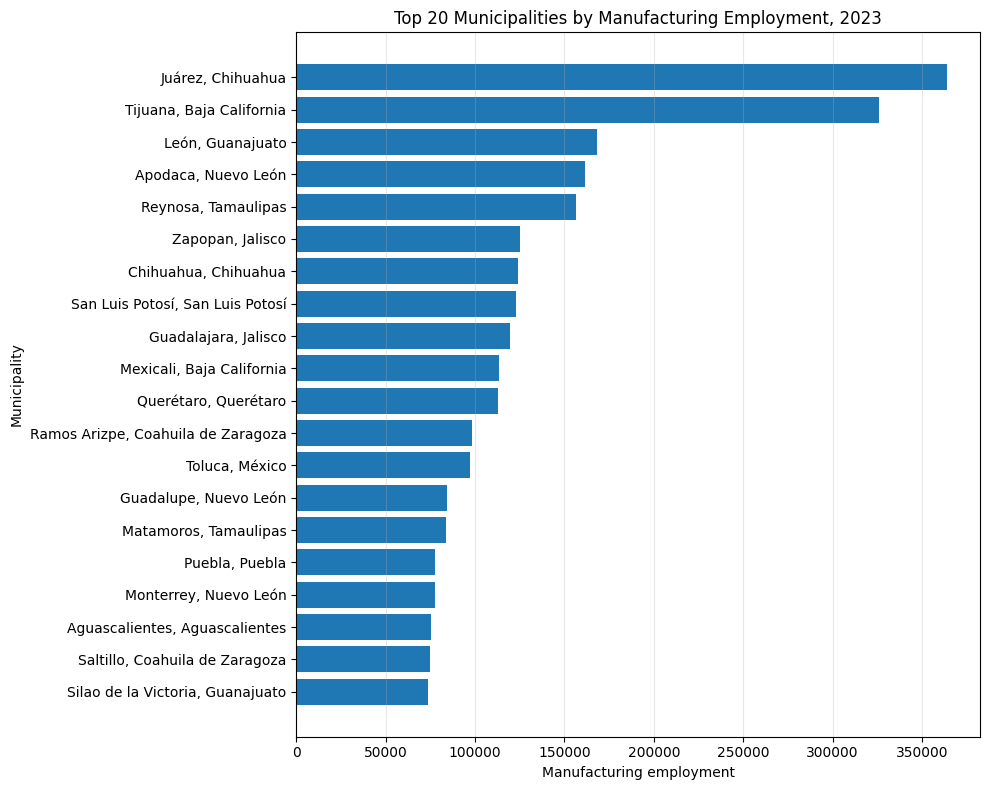

Figura guardada en: /content/drive/MyDrive/Nearshoring_Project/outputs/figures/top20_manufacturing_value_added_2023.png


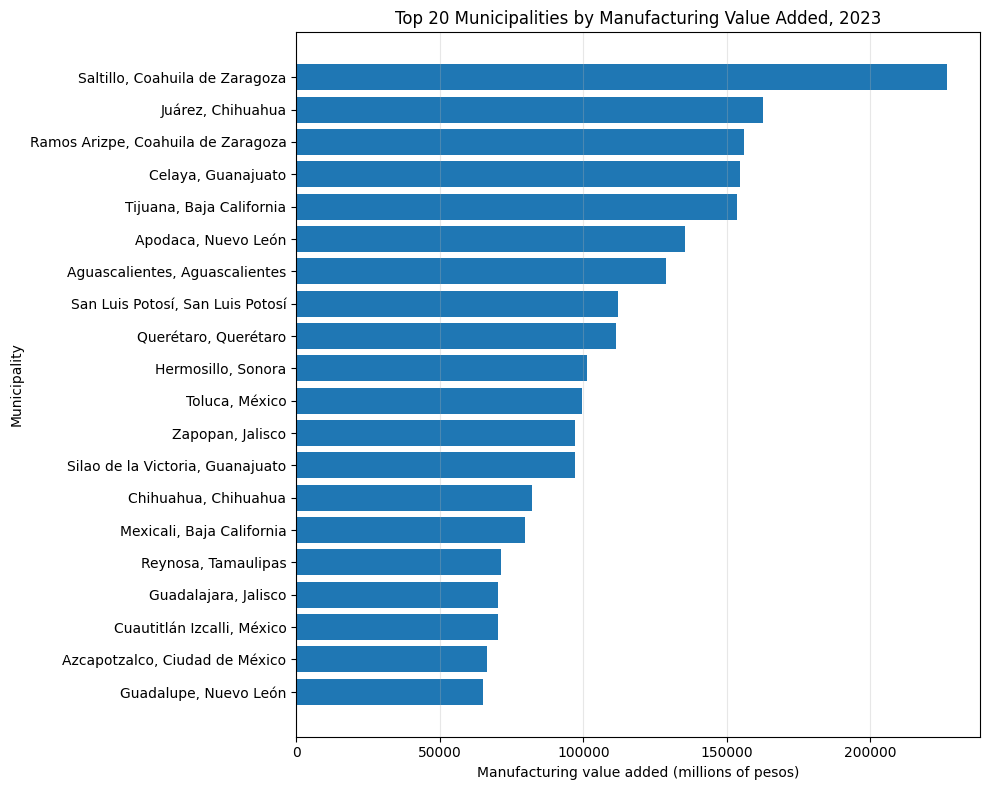

Figura guardada en: /content/drive/MyDrive/Nearshoring_Project/outputs/figures/scatter_employment_vs_value_added_2023.png


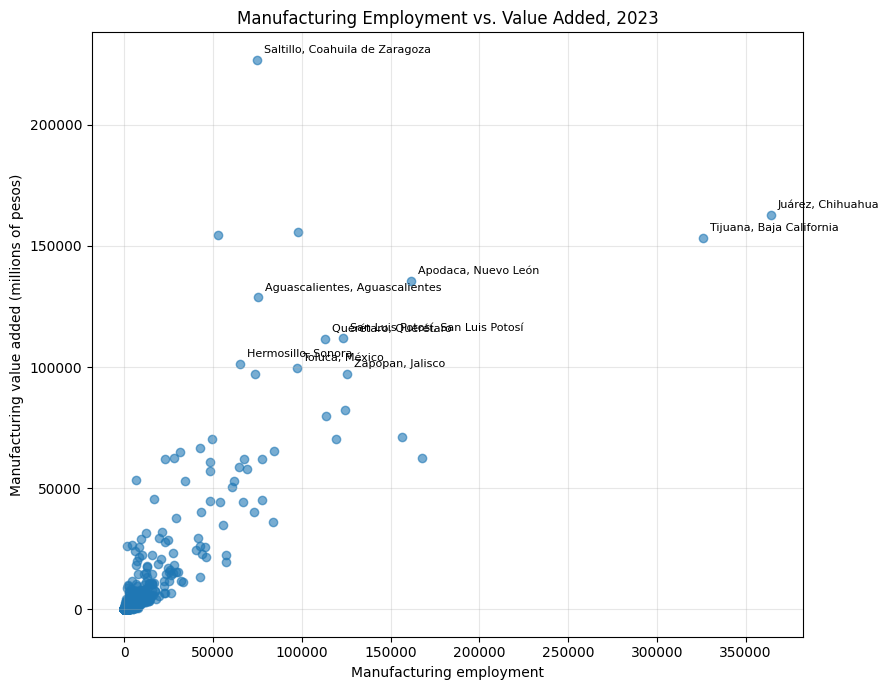


Top 20 municipios por industrial_capacity_score, 2023:


,year,rank_industrial_capacity_within_year,industrial_capacity_score,industrial_capacity_percentile,industrial_capacity_group,entidad_name,municipio_name,geo_key,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,number_of_manufacturing_scian_activities
9587,2023,1.0,0.992587,1.000000,Top industrial hub,Coahuila de Zaragoza,Saltillo,05030,74640.0,226838.388,2758.0,21
9588,2023,2.0,0.991693,0.999562,Top industrial hub,San Luis Potosí,San Luis Potosí,24028,122990.0,112107.049,3545.0,21
9589,2023,3.0,0.991194,0.999125,Top industrial hub,Querétaro,Querétaro,22014,112895.0,111460.482,3544.0,21
9590,2023,4.0,0.990765,0.998687,Top industrial hub,Aguascalientes,Aguascalientes,01001,75556.0,128718.721,4166.0,21
9591,2023,5.0,0.990511,0.998249,Top industrial hub,México,Toluca,15106,97042.0,99527.258,5132.0,21
9592,2023,6.0,0.990424,0.997812,Top industrial hub,Baja California,Tijuana,02004,325983.0,153382.823,3977.0,21
9593,2023,7.0,0.989973,0.997374,Top industrial hub,Jalisco,Zapopan,14120,125448.0,96995.655,4454.0,21
9594,2023,8.0,0.989296,0.996937,Top industrial hub,Chihuahua,Juárez,08037,364180.0,162648.251,2631.0,21
9595,2023,9.0,0.988516,0.996499,Top industrial hub,Sonora,Hermosillo,26030,65023.0,101436.591,4034.0,21
9596,2023,10.0,0.988226,0.996061,Top industrial hub,Nuevo León,Apodaca,19006,161584.0,135425.566,1597.0,20



Tabla top 20 guardada en:
/content/drive/MyDrive/Nearshoring_Project/outputs/top20_industrial_capacity_score_2023.csv


In [2]:
# ============================================================
# 05_create_initial_figures_2023.py
# Project: Nearshoring B2B Opportunity Mexico
# Goal: Create initial exploratory figures for 2023
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Mount Google Drive if needed
# ------------------------------------------------------------

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
FIGURES_DIR = f"{PROJECT_DIR}/outputs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

possible_files = glob.glob(
    f"{PROJECT_DIR}/**/municipality_industrial_capacity_panel.csv",
    recursive=True
)

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No encontré municipality_industrial_capacity_panel.csv dentro de Nearshoring_Project."
    )

input_path = possible_files[0]

print("Archivo usado:")
print(input_path)

print("\nCarpeta de salida para figuras:")
print(FIGURES_DIR)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

panel = pd.read_csv(
    input_path,
    dtype={
        "year": str,
        "entidad_id": str,
        "municipio_id": str,
        "geo_key": str
    }
)

print("\nBase cargada:")
print(panel.shape)

print("\nAños disponibles:")
print(sorted(panel["year"].dropna().unique()))

# ------------------------------------------------------------
# 3. Filter 2023
# ------------------------------------------------------------

panel_2023 = panel[panel["year"] == "2023"].copy()

print("\nBase filtrada para 2023:")
print(panel_2023.shape)

if panel_2023.empty:
    raise ValueError("No hay observaciones para 2023.")

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def make_municipality_label(df):
    return df["municipio_name"].astype(str) + ", " + df["entidad_name"].astype(str)

def save_and_show(fig, filename):
    output_path = f"{FIGURES_DIR}/{filename}"
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print("Figura guardada en:", output_path)
    plt.show()

def plot_top_20_bar(data, variable, title, xlabel, filename):
    top_20 = (
        data
        .sort_values(variable, ascending=False)
        .head(20)
        .copy()
    )

    top_20["municipality_label"] = make_municipality_label(top_20)

    # Sort ascending for horizontal bar readability
    top_20 = top_20.sort_values(variable, ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(
        top_20["municipality_label"],
        top_20[variable]
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Municipality")
    ax.grid(axis="x", alpha=0.3)

    save_and_show(fig, filename)

# ------------------------------------------------------------
# 5. Figure 1: Top 20 by industrial capacity score
# ------------------------------------------------------------

plot_top_20_bar(
    data=panel_2023,
    variable="industrial_capacity_score",
    title="Top 20 Municipalities by Industrial Capacity Score, 2023",
    xlabel="Industrial capacity score",
    filename="top20_industrial_capacity_score_2023.png"
)

# ------------------------------------------------------------
# 6. Figure 2: Top 20 by manufacturing employment
# ------------------------------------------------------------

plot_top_20_bar(
    data=panel_2023,
    variable="total_manufacturing_employment",
    title="Top 20 Municipalities by Manufacturing Employment, 2023",
    xlabel="Manufacturing employment",
    filename="top20_manufacturing_employment_2023.png"
)

# ------------------------------------------------------------
# 7. Figure 3: Top 20 by manufacturing value added
# ------------------------------------------------------------

plot_top_20_bar(
    data=panel_2023,
    variable="total_manufacturing_value_added",
    title="Top 20 Municipalities by Manufacturing Value Added, 2023",
    xlabel="Manufacturing value added (millions of pesos)",
    filename="top20_manufacturing_value_added_2023.png"
)

# ------------------------------------------------------------
# 8. Figure 4: Employment vs value added
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    panel_2023["total_manufacturing_employment"],
    panel_2023["total_manufacturing_value_added"],
    alpha=0.6
)

ax.set_title("Manufacturing Employment vs. Value Added, 2023")
ax.set_xlabel("Manufacturing employment")
ax.set_ylabel("Manufacturing value added (millions of pesos)")
ax.grid(alpha=0.3)

# Label top municipalities by industrial capacity score
top_labels = (
    panel_2023
    .sort_values("industrial_capacity_score", ascending=False)
    .head(10)
    .copy()
)

for _, row in top_labels.iterrows():
    label = f"{row['municipio_name']}, {row['entidad_name']}"
    ax.annotate(
        label,
        (
            row["total_manufacturing_employment"],
            row["total_manufacturing_value_added"]
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

save_and_show(
    fig,
    "scatter_employment_vs_value_added_2023.png"
)

# ------------------------------------------------------------
# 9. Optional validation table: top 20 by score
# ------------------------------------------------------------

top20_score = (
    panel_2023
    .sort_values("rank_industrial_capacity_within_year", ascending=True)
    [
        [
            "year",
            "rank_industrial_capacity_within_year",
            "industrial_capacity_score",
            "industrial_capacity_percentile",
            "industrial_capacity_group",
            "entidad_name",
            "municipio_name",
            "geo_key",
            "total_manufacturing_employment",
            "total_manufacturing_value_added",
            "total_manufacturing_establishments",
            "number_of_manufacturing_scian_activities"
        ]
    ]
    .head(20)
)

print("\nTop 20 municipios por industrial_capacity_score, 2023:")
display(top20_score)

# Save validation table
top20_output_path = f"{PROJECT_DIR}/outputs/top20_industrial_capacity_score_2023.csv"
os.makedirs(f"{PROJECT_DIR}/outputs", exist_ok=True)

top20_score.to_csv(
    top20_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla top 20 guardada en:")
print(top20_output_path)

In [3]:
# ============================================================
# 06_create_initial_tables_2023.py
# Project: Nearshoring B2B Opportunity Mexico
# Goal: Create tables to answer initial manufacturing questions
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. Mount Google Drive if needed
# ------------------------------------------------------------

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
TABLES_DIR = f"{PROJECT_DIR}/outputs/tables"

os.makedirs(TABLES_DIR, exist_ok=True)

possible_files = glob.glob(
    f"{PROJECT_DIR}/**/municipality_industrial_capacity_panel.csv",
    recursive=True
)

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No encontré municipality_industrial_capacity_panel.csv dentro de Nearshoring_Project."
    )

input_path = possible_files[0]

print("Archivo usado:")
print(input_path)

print("\nCarpeta de salida para tablas:")
print(TABLES_DIR)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

panel = pd.read_csv(
    input_path,
    dtype={
        "year": str,
        "entidad_id": str,
        "municipio_id": str,
        "geo_key": str
    }
)

print("\nBase cargada:")
print(panel.shape)

print("\nAños disponibles:")
print(sorted(panel["year"].dropna().unique()))

# ------------------------------------------------------------
# 3. Filter 2023
# ------------------------------------------------------------

panel_2023 = panel[panel["year"] == "2023"].copy()

print("\nBase filtrada para 2023:")
print(panel_2023.shape)

if panel_2023.empty:
    raise ValueError("No hay observaciones para 2023.")

# ------------------------------------------------------------
# 4. Helper function to create ranking tables
# ------------------------------------------------------------

def create_ranking_table(data, metric, question, top_n=20):
    """
    Creates a clean top-N table for a specific metric.
    """

    required_cols = [
        "year",
        "entidad_name",
        "municipio_name",
        "geo_key",
        metric,
        "industrial_capacity_score",
        "industrial_capacity_percentile",
        "rank_industrial_capacity_within_year",
        "industrial_capacity_group",
        "total_manufacturing_employment",
        "total_manufacturing_value_added",
        "total_manufacturing_establishments",
        "number_of_manufacturing_scian_activities",
        "manufacturing_value_added_per_worker"
    ]

    available_cols = [col for col in required_cols if col in data.columns]

    table = (
        data
        .sort_values(metric, ascending=False)
        .head(top_n)
        .copy()
    )

    table["question"] = question
    table["metric"] = metric
    table["metric_rank"] = range(1, len(table) + 1)

    final_cols = [
        "question",
        "metric",
        "metric_rank"
    ] + available_cols

    table = table[final_cols].copy()

    return table

# ------------------------------------------------------------
# 5. Define questions and metrics
# ------------------------------------------------------------

top_n = 20

questions = {
    "main_manufacturing_municipalities_2023": {
        "question": "Principales municipios manufactureros en 2023, según el índice compuesto de capacidad manufacturera",
        "metric": "industrial_capacity_score"
    },
    "top_manufacturing_employment_2023": {
        "question": "Municipios con más empleo manufacturero en 2023",
        "metric": "total_manufacturing_employment"
    },
    "top_manufacturing_value_added_2023": {
        "question": "Municipios con más valor agregado manufacturero en 2023",
        "metric": "total_manufacturing_value_added"
    },
    "top_manufacturing_establishments_2023": {
        "question": "Municipios con más establecimientos manufactureros en 2023",
        "metric": "total_manufacturing_establishments"
    },
    "top_value_added_per_worker_2023": {
        "question": "Municipios con mayor valor agregado manufacturero por trabajador en 2023",
        "metric": "manufacturing_value_added_per_worker"
    },
    "top_manufacturing_diversity_2023": {
        "question": "Municipios con mayor diversidad manufacturera en 2023",
        "metric": "number_of_manufacturing_scian_activities"
    },
    "top_relative_industrial_capacity_2023": {
        "question": "Municipios con mayor capacidad manufacturera instalada relativa en 2023",
        "metric": "industrial_capacity_percentile"
    }
}

# ------------------------------------------------------------
# 6. Create ranking tables
# ------------------------------------------------------------

ranking_tables = {}

for file_label, info in questions.items():
    metric = info["metric"]
    question = info["question"]

    if metric not in panel_2023.columns:
        raise KeyError(f"No encontré la variable requerida: {metric}")

    table = create_ranking_table(
        data=panel_2023,
        metric=metric,
        question=question,
        top_n=top_n
    )

    ranking_tables[file_label] = table

# ------------------------------------------------------------
# 7. Display all tables
# ------------------------------------------------------------

for file_label, table in ranking_tables.items():
    print("\n" + "=" * 110)
    print(questions[file_label]["question"])
    print("=" * 110)
    display(table)

# ------------------------------------------------------------
# 8. Save individual tables
# ------------------------------------------------------------

for file_label, table in ranking_tables.items():
    output_path = f"{TABLES_DIR}/{file_label}.csv"

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Tabla guardada:", output_path)

# ------------------------------------------------------------
# 9. Create consolidated long table
# ------------------------------------------------------------

manufacturing_questions_2023_long = pd.concat(
    ranking_tables.values(),
    ignore_index=True
)

long_output_path = f"{TABLES_DIR}/manufacturing_questions_2023_long.csv"

manufacturing_questions_2023_long.to_csv(
    long_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla consolidada larga guardada en:")
print(long_output_path)

# ------------------------------------------------------------
# 10. Create compact table for presentation
# ------------------------------------------------------------

compact_cols = [
    "question",
    "metric_rank",
    "entidad_name",
    "municipio_name",
    "geo_key",
    "metric",
    "industrial_capacity_score",
    "industrial_capacity_percentile",
    "rank_industrial_capacity_within_year",
    "industrial_capacity_group"
]

compact_cols = [
    col for col in compact_cols
    if col in manufacturing_questions_2023_long.columns
]

manufacturing_questions_2023_compact = (
    manufacturing_questions_2023_long[compact_cols]
    .copy()
)

compact_output_path = f"{TABLES_DIR}/manufacturing_questions_2023_compact.csv"

manufacturing_questions_2023_compact.to_csv(
    compact_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla compacta guardada en:")
print(compact_output_path)

display(manufacturing_questions_2023_compact.head(50))

# ------------------------------------------------------------
# 11. Create wide summary: top 10 by question
# ------------------------------------------------------------

top10_wide_parts = []

for file_label, table in ranking_tables.items():
    temp = table.head(10).copy()
    temp["municipality_label"] = (
        temp["municipio_name"].astype(str) + ", " + temp["entidad_name"].astype(str)
    )

    temp = temp[
        [
            "metric_rank",
            "municipality_label",
            "geo_key"
        ]
    ].copy()

    question_short = file_label.replace("_2023", "")

    temp = temp.rename(columns={
        "municipality_label": f"{question_short}_municipality",
        "geo_key": f"{question_short}_geo_key"
    })

    temp = temp.set_index("metric_rank")

    top10_wide_parts.append(temp)

top10_wide = pd.concat(top10_wide_parts, axis=1).reset_index()

wide_output_path = f"{TABLES_DIR}/manufacturing_questions_2023_top10_wide.csv"

top10_wide.to_csv(
    wide_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla wide top 10 guardada en:")
print(wide_output_path)

display(top10_wide)

# ------------------------------------------------------------
# 12. Quick interpretation table: top 20 by final score
# ------------------------------------------------------------

interpretation_table = (
    panel_2023
    .sort_values("rank_industrial_capacity_within_year", ascending=True)
    [
        [
            "year",
            "rank_industrial_capacity_within_year",
            "industrial_capacity_score",
            "industrial_capacity_percentile",
            "industrial_capacity_group",
            "entidad_name",
            "municipio_name",
            "geo_key",
            "total_manufacturing_employment",
            "total_manufacturing_value_added",
            "total_manufacturing_establishments",
            "manufacturing_value_added_per_worker",
            "number_of_manufacturing_scian_activities"
        ]
    ]
    .head(20)
    .copy()
)

interpretation_output_path = f"{TABLES_DIR}/top20_industrial_capacity_interpretation_2023.csv"

interpretation_table.to_csv(
    interpretation_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla de interpretación top 20 guardada en:")
print(interpretation_output_path)

display(interpretation_table)

Google Drive ya está montado.
Archivo usado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_capacity_panel.csv

Carpeta de salida para tablas:
/content/drive/MyDrive/Nearshoring_Project/outputs/tables

Base cargada:
(12038, 38)

Años disponibles:
['2003', '2008', '2013', '2018', '2023']

Base filtrada para 2023:
(2451, 38)

Principales municipios manufactureros en 2023, según el índice compuesto de capacidad manufacturera


,question,metric,metric_rank,year,entidad_name,municipio_name,geo_key,industrial_capacity_score,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,number_of_manufacturing_scian_activities,manufacturing_value_added_per_worker
9587,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,1,2023,Coahuila de Zaragoza,Saltillo,05030,0.992587,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,21,3.039100
9588,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,2,2023,San Luis Potosí,San Luis Potosí,24028,0.991693,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,21,0.911514
9589,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,3,2023,Querétaro,Querétaro,22014,0.991194,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,21,0.987293
9590,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,4,2023,Aguascalientes,Aguascalientes,01001,0.990765,0.990765,0.998687,4.0,Top industrial hub,75556.0,128718.721,4166.0,21,1.703620
9591,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,5,2023,México,Toluca,15106,0.990511,0.990511,0.998249,5.0,Top industrial hub,97042.0,99527.258,5132.0,21,1.025610
9592,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,6,2023,Baja California,Tijuana,02004,0.990424,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,21,0.470524
9593,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,7,2023,Jalisco,Zapopan,14120,0.989973,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,21,0.773194
9594,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,8,2023,Chihuahua,Juárez,08037,0.989296,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,21,0.446615
9595,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,9,2023,Sonora,Hermosillo,26030,0.988516,0.988516,0.996499,9.0,Top industrial hub,65023.0,101436.591,4034.0,21,1.560011
9596,"Principales municipios manufactureros en 2023,...",industrial_capacity_score,10,2023,Nuevo León,Apodaca,19006,0.988226,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,20,0.838112



Municipios con más empleo manufacturero en 2023


,question,metric,metric_rank,year,entidad_name,municipio_name,geo_key,total_manufacturing_employment,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,number_of_manufacturing_scian_activities,manufacturing_value_added_per_worker
9594,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,1,2023,Chihuahua,Juárez,08037,364180.0,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,21,0.446615
9592,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,2,2023,Baja California,Tijuana,02004,325983.0,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,21,0.470524
9605,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,3,2023,Guanajuato,León,11020,167948.0,0.982773,0.992123,19.0,Top industrial hub,167948.0,62485.075,12015.0,21,0.372050
9596,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,4,2023,Nuevo León,Apodaca,19006,161584.0,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,20,0.838112
9612,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,5,2023,Tamaulipas,Reynosa,28032,156496.0,0.980458,0.989059,26.0,Top industrial hub,156496.0,71263.586,1520.0,20,0.455370
9593,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,6,2023,Jalisco,Zapopan,14120,125448.0,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,21,0.773194
9597,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,7,2023,Chihuahua,Chihuahua,08019,124212.0,0.988070,0.995624,11.0,Top industrial hub,124212.0,82162.198,2952.0,21,0.661467
9588,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,8,2023,San Luis Potosí,San Luis Potosí,24028,122990.0,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,21,0.911514
9602,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,9,2023,Jalisco,Guadalajara,14039,119521.0,0.986042,0.993435,16.0,Top industrial hub,119521.0,70446.836,7684.0,21,0.589410
9599,Municipios con más empleo manufacturero en 2023,total_manufacturing_employment,10,2023,Baja California,Mexicali,02002,113604.0,0.987463,0.994748,13.0,Top industrial hub,113604.0,79684.630,2454.0,21,0.701425



Municipios con más valor agregado manufacturero en 2023


...

,question,metric,metric_rank,year,entidad_name,municipio_name,geo_key,number_of_manufacturing_scian_activities,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,number_of_manufacturing_scian_activities,manufacturing_value_added_per_worker
9615,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,1,2023,Nuevo León,San Nicolás de los Garza,19046,21,0.979311,0.987746,29.0,Top industrial hub,48367.0,56902.707,1080.0,21,1.176478
9587,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,2,2023,Coahuila de Zaragoza,Saltillo,05030,21,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,21,3.039100
9588,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,3,2023,San Luis Potosí,San Luis Potosí,24028,21,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,21,0.911514
9589,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,4,2023,Querétaro,Querétaro,22014,21,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,21,0.987293
9602,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,5,2023,Jalisco,Guadalajara,14039,21,0.986042,0.993435,16.0,Top industrial hub,119521.0,70446.836,7684.0,21,0.589410
9601,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,6,2023,Nuevo León,Monterrey,19039,21,0.986152,0.993873,15.0,Top industrial hub,77374.0,62184.929,4957.0,21,0.803693
9600,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,7,2023,Nuevo León,Guadalupe,19026,21,0.986194,0.994311,14.0,Top industrial hub,84572.0,65230.449,1958.0,21,0.771301
9599,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,8,2023,Baja California,Mexicali,02002,21,0.987463,0.994748,13.0,Top industrial hub,113604.0,79684.630,2454.0,21,0.701425
9598,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,9,2023,Guanajuato,Celaya,11007,21,0.988008,0.995186,12.0,Top industrial hub,52830.0,154528.463,1625.0,21,2.925013
9597,Municipios con mayor diversidad manufacturera ...,number_of_manufacturing_scian_activities,10,2023,Chihuahua,Chihuahua,08019,21,0.988070,0.995624,11.0,Top industrial hub,124212.0,82162.198,2952.0,21,0.661467



Municipios con mayor capacidad manufacturera instalada relativa en 2023


,question,metric,metric_rank,year,entidad_name,municipio_name,geo_key,industrial_capacity_percentile,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,number_of_manufacturing_scian_activities,manufacturing_value_added_per_worker
9587,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,1,2023,Coahuila de Zaragoza,Saltillo,05030,1.000000,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,21,3.039100
9588,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,2,2023,San Luis Potosí,San Luis Potosí,24028,0.999562,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,21,0.911514
9589,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,3,2023,Querétaro,Querétaro,22014,0.999125,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,21,0.987293
9590,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,4,2023,Aguascalientes,Aguascalientes,01001,0.998687,0.990765,0.998687,4.0,Top industrial hub,75556.0,128718.721,4166.0,21,1.703620
9591,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,5,2023,México,Toluca,15106,0.998249,0.990511,0.998249,5.0,Top industrial hub,97042.0,99527.258,5132.0,21,1.025610
9592,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,6,2023,Baja California,Tijuana,02004,0.997812,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,21,0.470524
9593,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,7,2023,Jalisco,Zapopan,14120,0.997374,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,21,0.773194
9594,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,8,2023,Chihuahua,Juárez,08037,0.996937,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,21,0.446615
9595,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,9,2023,Sonora,Hermosillo,26030,0.996499,0.988516,0.996499,9.0,Top industrial hub,65023.0,101436.591,4034.0,21,1.560011
9596,Municipios con mayor capacidad manufacturera i...,industrial_capacity_percentile,10,2023,Nuevo León,Apodaca,19006,0.996061,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,20,0.838112


Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/main_manufacturing_municipalities_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_manufacturing_employment_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_manufacturing_value_added_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_manufacturing_establishments_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_value_added_per_worker_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_manufacturing_diversity_2023.csv
Tabla guardada: /content/drive/MyDrive/Nearshoring_Project/outputs/tables/top_relative_industrial_capacity_2023.csv


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [4]:
# ============================================================
# 06_create_single_table_by_question_2023_FIXED.py
# Project: Nearshoring B2B Opportunity Mexico
# Goal: Create one table organized by analytical question
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
TABLES_DIR = f"{PROJECT_DIR}/outputs/tables"

os.makedirs(TABLES_DIR, exist_ok=True)

possible_files = glob.glob(
    f"{PROJECT_DIR}/**/municipality_industrial_capacity_panel.csv",
    recursive=True
)

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No encontré municipality_industrial_capacity_panel.csv dentro de Nearshoring_Project."
    )

input_path = possible_files[0]

print("Archivo usado:")
print(input_path)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

panel = pd.read_csv(
    input_path,
    dtype={
        "year": str,
        "entidad_id": str,
        "municipio_id": str,
        "geo_key": str
    }
)

panel_2023 = panel[panel["year"] == "2023"].copy()

if panel_2023.empty:
    raise ValueError("No hay observaciones para 2023.")

print("Base 2023:")
print(panel_2023.shape)

# ------------------------------------------------------------
# 3. Define questions
# ------------------------------------------------------------

questions = [
    {
        "question_id": "q1_main_manufacturing_municipalities",
        "question": "¿Cuáles son los principales municipios manufactureros en 2023?",
        "metric": "industrial_capacity_score",
        "metric_label": "Índice compuesto de capacidad manufacturera"
    },
    {
        "question_id": "q2_top_employment",
        "question": "¿Cuáles tienen más empleo manufacturero?",
        "metric": "total_manufacturing_employment",
        "metric_label": "Empleo manufacturero total"
    },
    {
        "question_id": "q3_top_value_added",
        "question": "¿Cuáles tienen más valor agregado manufacturero?",
        "metric": "total_manufacturing_value_added",
        "metric_label": "Valor agregado manufacturero total"
    },
    {
        "question_id": "q4_top_establishments",
        "question": "¿Cuáles tienen más establecimientos manufactureros?",
        "metric": "total_manufacturing_establishments",
        "metric_label": "Establecimientos manufactureros"
    },
    {
        "question_id": "q5_top_value_added_per_worker",
        "question": "¿Cuáles tienen mayor valor agregado manufacturero por trabajador?",
        "metric": "manufacturing_value_added_per_worker",
        "metric_label": "Valor agregado manufacturero por trabajador"
    },
    {
        "question_id": "q6_top_industrial_diversity",
        "question": "¿Cuáles tienen mayor diversidad manufacturera?",
        "metric": "number_of_manufacturing_scian_activities",
        "metric_label": "Número de actividades manufactureras SCIAN"
    },
    {
        "question_id": "q7_top_relative_industrial_capacity",
        "question": "¿Qué municipios tienen mayor capacidad manufacturera instalada, comparados con otros municipios en el mismo año?",
        "metric": "industrial_capacity_percentile",
        "metric_label": "Percentil del índice compuesto de capacidad manufacturera"
    }
]

# ------------------------------------------------------------
# 4. Function to create one question table
# ------------------------------------------------------------

def create_question_table(data, question_info, top_n=20):
    metric = question_info["metric"]

    if metric not in data.columns:
        raise KeyError(f"No encontré la variable requerida: {metric}")

    table = (
        data
        .sort_values(metric, ascending=False)
        .head(top_n)
        .copy()
    )

    table["question_id"] = question_info["question_id"]
    table["question"] = question_info["question"]
    table["metric"] = metric
    table["metric_label"] = question_info["metric_label"]
    table["metric_value"] = table[metric]
    table["metric_rank"] = range(1, len(table) + 1)

    keep_cols = [
        "question_id",
        "question",
        "metric",
        "metric_label",
        "metric_rank",
        "year",
        "entidad_name",
        "municipio_name",
        "geo_key",
        "metric_value",
        "industrial_capacity_score",
        "industrial_capacity_percentile",
        "rank_industrial_capacity_within_year",
        "industrial_capacity_group",
        "total_manufacturing_employment",
        "total_manufacturing_value_added",
        "total_manufacturing_establishments",
        "manufacturing_value_added_per_worker",
        "number_of_manufacturing_scian_activities"
    ]

    # Mantener solo columnas existentes
    keep_cols = [col for col in keep_cols if col in table.columns]

    # Eliminar columnas duplicadas manteniendo el orden
    keep_cols = list(dict.fromkeys(keep_cols))

    table = table[keep_cols].copy()

    # Validación: no debe haber columnas duplicadas
    if table.columns.duplicated().any():
        duplicated_cols = table.columns[table.columns.duplicated()].tolist()
        raise ValueError(f"La tabla tiene columnas duplicadas: {duplicated_cols}")

    return table

# ------------------------------------------------------------
# 5. Create one consolidated table by question
# ------------------------------------------------------------

top_n = 20

tables = []

for q in questions:
    q_table = create_question_table(panel_2023, q, top_n=top_n)
    tables.append(q_table)

questions_table = pd.concat(tables, ignore_index=True)

# ------------------------------------------------------------
# 6. Save one output
# ------------------------------------------------------------

output_path = f"{TABLES_DIR}/manufacturing_questions_2023_by_question.csv"

questions_table.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla única guardada en:")
print(output_path)

print("\nDimensiones:")
print(questions_table.shape)

# ------------------------------------------------------------
# 7. Display by question
# ------------------------------------------------------------

for q in questions_table["question"].unique():
    print("\n" + "=" * 120)
    print(q)
    print("=" * 120)
    display(
        questions_table[questions_table["question"] == q]
        .sort_values("metric_rank")
    )

Google Drive ya está montado.
Archivo usado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_capacity_panel.csv
Base 2023:
(2451, 38)

Tabla única guardada en:
/content/drive/MyDrive/Nearshoring_Project/outputs/tables/manufacturing_questions_2023_by_question.csv

Dimensiones:
(140, 19)

¿Cuáles son los principales municipios manufactureros en 2023?


,question_id,question,metric,metric_label,metric_rank,year,entidad_name,municipio_name,geo_key,metric_value,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,manufacturing_value_added_per_worker,number_of_manufacturing_scian_activities
0,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,1,2023,Coahuila de Zaragoza,Saltillo,05030,0.992587,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,3.039100,21
1,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,2,2023,San Luis Potosí,San Luis Potosí,24028,0.991693,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,0.911514,21
2,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,3,2023,Querétaro,Querétaro,22014,0.991194,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,0.987293,21
3,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,4,2023,Aguascalientes,Aguascalientes,01001,0.990765,0.990765,0.998687,4.0,Top industrial hub,75556.0,128718.721,4166.0,1.703620,21
4,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,5,2023,México,Toluca,15106,0.990511,0.990511,0.998249,5.0,Top industrial hub,97042.0,99527.258,5132.0,1.025610,21
5,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,6,2023,Baja California,Tijuana,02004,0.990424,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,0.470524,21
6,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,7,2023,Jalisco,Zapopan,14120,0.989973,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,0.773194,21
7,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,8,2023,Chihuahua,Juárez,08037,0.989296,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,0.446615,21
8,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,9,2023,Sonora,Hermosillo,26030,0.988516,0.988516,0.996499,9.0,Top industrial hub,65023.0,101436.591,4034.0,1.560011,21
9,q1_main_manufacturing_municipalities,¿Cuáles son los principales municipios manufac...,industrial_capacity_score,Índice compuesto de capacidad manufacturera,10,2023,Nuevo León,Apodaca,19006,0.988226,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,0.838112,20



¿Cuáles tienen más empleo manufacturero?


,question_id,question,metric,metric_label,metric_rank,year,entidad_name,municipio_name,geo_key,metric_value,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,manufacturing_value_added_per_worker,number_of_manufacturing_scian_activities
20,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,1,2023,Chihuahua,Juárez,08037,364180.0,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,0.446615,21
21,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,2,2023,Baja California,Tijuana,02004,325983.0,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,0.470524,21
22,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,3,2023,Guanajuato,León,11020,167948.0,0.982773,0.992123,19.0,Top industrial hub,167948.0,62485.075,12015.0,0.372050,21
23,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,4,2023,Nuevo León,Apodaca,19006,161584.0,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,0.838112,20
24,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,5,2023,Tamaulipas,Reynosa,28032,156496.0,0.980458,0.989059,26.0,Top industrial hub,156496.0,71263.586,1520.0,0.455370,20
25,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,6,2023,Jalisco,Zapopan,14120,125448.0,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,0.773194,21
26,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,7,2023,Chihuahua,Chihuahua,08019,124212.0,0.988070,0.995624,11.0,Top industrial hub,124212.0,82162.198,2952.0,0.661467,21
27,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,8,2023,San Luis Potosí,San Luis Potosí,24028,122990.0,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,0.911514,21
28,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,9,2023,Jalisco,Guadalajara,14039,119521.0,0.986042,0.993435,16.0,Top industrial hub,119521.0,70446.836,7684.0,0.589410,21
29,q2_top_employment,¿Cuáles tienen más empleo manufacturero?,total_manufacturing_employment,Empleo manufacturero total,10,2023,Baja California,Mexicali,02002,113604.0,0.987463,0.994748,13.0,Top industrial hub,113604.0,79684.630,2454.0,0.701425,21



¿Cuáles tienen más valor agregado manufacturero?


...

,question_id,question,metric,metric_label,metric_rank,year,entidad_name,municipio_name,geo_key,metric_value,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,manufacturing_value_added_per_worker,number_of_manufacturing_scian_activities
80,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,1,2023,Sonora,Nacozari de García,26041,17.144295,0.812658,0.843326,359.0,Relevant industrial base,1532.0,26265.060,55.0,17.144295,10
81,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,2,2023,Coahuila de Zaragoza,Nava,05022,7.774553,0.887789,0.910284,206.0,Strong industrial municipality,6848.0,53240.142,100.0,7.774553,13
82,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,3,2023,Veracruz de Ignacio de la Llave,Apazapan,30017,7.046492,0.619836,0.621882,865.0,Moderate industrial base,240.0,1691.158,12.0,7.046492,4
83,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,4,2023,Oaxaca,Salina Cruz,20079,6.147172,0.936591,0.952735,109.0,Top industrial hub,4330.0,26617.255,516.0,6.147172,18
84,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,5,2023,Hidalgo,Apan,13008,5.187321,0.869685,0.892341,247.0,Relevant industrial base,1892.0,9814.411,257.0,5.187321,12
85,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,6,2023,Veracruz de Ignacio de la Llave,Ixhuatlán del Sureste,30082,4.885092,0.638673,0.647702,806.0,Moderate industrial base,153.0,747.419,40.0,4.885092,9
86,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,7,2023,Veracruz de Ignacio de la Llave,Cosoleacaque,30048,4.650067,0.899275,0.917724,189.0,Strong industrial municipality,1843.0,8570.074,502.0,4.650067,17
87,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,8,2023,Hidalgo,Santiago de Anaya,13055,4.605630,0.733356,0.747921,577.0,Moderate industrial base,408.0,1879.097,73.0,4.605630,10
88,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,9,2023,Veracruz de Ignacio de la Llave,Chinameca,30059,4.407713,0.776056,0.799125,460.0,Relevant industrial base,941.0,4147.658,67.0,4.407713,9
89,q5_top_value_added_per_worker,¿Cuáles tienen mayor valor agregado manufactur...,manufacturing_value_added_per_worker,Valor agregado manufacturero por trabajador,10,2023,Chiapas,Reforma,07074,4.205288,0.872235,0.895405,240.0,Relevant industrial base,2318.0,9747.858,161.0,4.205288,13



¿Cuáles tienen mayor diversidad manufacturera?


,question_id,question,metric,metric_label,metric_rank,year,entidad_name,municipio_name,geo_key,metric_value,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,manufacturing_value_added_per_worker,number_of_manufacturing_scian_activities
100,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,1,2023,Nuevo León,San Nicolás de los Garza,19046,21.0,0.979311,0.987746,29.0,Top industrial hub,48367.0,56902.707,1080.0,1.176478,21
101,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,2,2023,Coahuila de Zaragoza,Saltillo,05030,21.0,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,3.039100,21
102,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,3,2023,San Luis Potosí,San Luis Potosí,24028,21.0,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,0.911514,21
103,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,4,2023,Querétaro,Querétaro,22014,21.0,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,0.987293,21
104,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,5,2023,Jalisco,Guadalajara,14039,21.0,0.986042,0.993435,16.0,Top industrial hub,119521.0,70446.836,7684.0,0.589410,21
105,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,6,2023,Nuevo León,Monterrey,19039,21.0,0.986152,0.993873,15.0,Top industrial hub,77374.0,62184.929,4957.0,0.803693,21
106,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,7,2023,Nuevo León,Guadalupe,19026,21.0,0.986194,0.994311,14.0,Top industrial hub,84572.0,65230.449,1958.0,0.771301,21
107,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,8,2023,Baja California,Mexicali,02002,21.0,0.987463,0.994748,13.0,Top industrial hub,113604.0,79684.630,2454.0,0.701425,21
108,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,9,2023,Guanajuato,Celaya,11007,21.0,0.988008,0.995186,12.0,Top industrial hub,52830.0,154528.463,1625.0,2.925013,21
109,q6_top_industrial_diversity,¿Cuáles tienen mayor diversidad manufacturera?,number_of_manufacturing_scian_activities,Número de actividades manufactureras SCIAN,10,2023,Chihuahua,Chihuahua,08019,21.0,0.988070,0.995624,11.0,Top industrial hub,124212.0,82162.198,2952.0,0.661467,21



¿Qué municipios tienen mayor capacidad manufacturera instalada, comparados con otros municipios en el mismo año?


,question_id,question,metric,metric_label,metric_rank,year,entidad_name,municipio_name,geo_key,metric_value,industrial_capacity_score,industrial_capacity_percentile,rank_industrial_capacity_within_year,industrial_capacity_group,total_manufacturing_employment,total_manufacturing_value_added,total_manufacturing_establishments,manufacturing_value_added_per_worker,number_of_manufacturing_scian_activities
120,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,1,2023,Coahuila de Zaragoza,Saltillo,05030,1.000000,0.992587,1.000000,1.0,Top industrial hub,74640.0,226838.388,2758.0,3.039100,21
121,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,2,2023,San Luis Potosí,San Luis Potosí,24028,0.999562,0.991693,0.999562,2.0,Top industrial hub,122990.0,112107.049,3545.0,0.911514,21
122,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,3,2023,Querétaro,Querétaro,22014,0.999125,0.991194,0.999125,3.0,Top industrial hub,112895.0,111460.482,3544.0,0.987293,21
123,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,4,2023,Aguascalientes,Aguascalientes,01001,0.998687,0.990765,0.998687,4.0,Top industrial hub,75556.0,128718.721,4166.0,1.703620,21
124,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,5,2023,México,Toluca,15106,0.998249,0.990511,0.998249,5.0,Top industrial hub,97042.0,99527.258,5132.0,1.025610,21
125,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,6,2023,Baja California,Tijuana,02004,0.997812,0.990424,0.997812,6.0,Top industrial hub,325983.0,153382.823,3977.0,0.470524,21
126,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,7,2023,Jalisco,Zapopan,14120,0.997374,0.989973,0.997374,7.0,Top industrial hub,125448.0,96995.655,4454.0,0.773194,21
127,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,8,2023,Chihuahua,Juárez,08037,0.996937,0.989296,0.996937,8.0,Top industrial hub,364180.0,162648.251,2631.0,0.446615,21
128,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,9,2023,Sonora,Hermosillo,26030,0.996499,0.988516,0.996499,9.0,Top industrial hub,65023.0,101436.591,4034.0,1.560011,21
129,q7_top_relative_industrial_capacity,¿Qué municipios tienen mayor capacidad manufac...,industrial_capacity_percentile,Percentil del índice compuesto de capacidad ma...,10,2023,Nuevo León,Apodaca,19006,0.996061,0.988226,0.996061,10.0,Top industrial hub,161584.0,135425.566,1597.0,0.838112,20


In [5]:
# ============================================================
# 07_generate_preliminary_report_2023.py
# Project: Nearshoring B2B Opportunity Mexico
# Goal: Generate an automated preliminary Markdown report
# ============================================================

import os
import glob
import pandas as pd
from datetime import date

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive ya está montado.")

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Nearshoring_Project"
REPORTS_DIR = f"{PROJECT_DIR}/outputs/reports"
TABLES_DIR = f"{PROJECT_DIR}/outputs/tables"

os.makedirs(REPORTS_DIR, exist_ok=True)

# Buscar tabla por preguntas
possible_question_tables = glob.glob(
    f"{PROJECT_DIR}/**/manufacturing_questions_2023_by_question.csv",
    recursive=True
)

if len(possible_question_tables) == 0:
    raise FileNotFoundError(
        "No encontré manufacturing_questions_2023_by_question.csv dentro del proyecto."
    )

questions_path = possible_question_tables[0]

# Buscar panel de capacidad industrial
possible_panel_files = glob.glob(
    f"{PROJECT_DIR}/**/municipality_industrial_capacity_panel.csv",
    recursive=True
)

if len(possible_panel_files) == 0:
    raise FileNotFoundError(
        "No encontré municipality_industrial_capacity_panel.csv dentro del proyecto."
    )

panel_path = possible_panel_files[0]

print("Tabla de preguntas usada:")
print(questions_path)

print("\nPanel usado:")
print(panel_path)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

questions_table = pd.read_csv(
    questions_path,
    dtype={
        "year": str,
        "geo_key": str
    }
)

panel = pd.read_csv(
    panel_path,
    dtype={
        "year": str,
        "geo_key": str,
        "entidad_id": str,
        "municipio_id": str
    }
)

panel_2023 = panel[panel["year"] == "2023"].copy()

if panel_2023.empty:
    raise ValueError("No hay observaciones para 2023 en el panel.")

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def format_number(x, decimals=0):
    """Format numbers for the report."""
    if pd.isna(x):
        return ""
    if decimals == 0:
        return f"{x:,.0f}"
    return f"{x:,.{decimals}f}"


def markdown_table(df, columns, rename_dict=None, max_rows=10):
    """
    Convert a pandas DataFrame into a simple Markdown table.
    """
    temp = df[columns].head(max_rows).copy()

    if rename_dict:
        temp = temp.rename(columns=rename_dict)

    return temp.to_markdown(index=False)


def get_question_block(question_id, max_rows=10):
    """
    Extract one question block from the consolidated questions table.
    """
    temp = questions_table[
        questions_table["question_id"] == question_id
    ].copy()

    temp = temp.sort_values("metric_rank").head(max_rows)

    return temp


def add_metric_value_formatted(df, decimals=0):
    """
    Adds formatted metric value for readable Markdown tables.
    """
    df = df.copy()
    df["metric_value_formatted"] = df["metric_value"].apply(
        lambda x: format_number(x, decimals=decimals)
    )
    return df

# ------------------------------------------------------------
# 4. Extract top tables
# ------------------------------------------------------------

top_capacity = (
    panel_2023
    .sort_values("rank_industrial_capacity_within_year", ascending=True)
    .head(10)
    .copy()
)

top_capacity["industrial_capacity_score_fmt"] = top_capacity["industrial_capacity_score"].apply(
    lambda x: format_number(x, decimals=3)
)

top_capacity["industrial_capacity_percentile_fmt"] = top_capacity["industrial_capacity_percentile"].apply(
    lambda x: format_number(x, decimals=3)
)

top_capacity["employment_fmt"] = top_capacity["total_manufacturing_employment"].apply(
    lambda x: format_number(x, decimals=0)
)

top_capacity["value_added_fmt"] = top_capacity["total_manufacturing_value_added"].apply(
    lambda x: format_number(x, decimals=1)
)

top_capacity["establishments_fmt"] = top_capacity["total_manufacturing_establishments"].apply(
    lambda x: format_number(x, decimals=0)
)

# Question-specific tables
q_employment = add_metric_value_formatted(
    get_question_block("q2_top_employment"),
    decimals=0
)

q_value_added = add_metric_value_formatted(
    get_question_block("q3_top_value_added"),
    decimals=1
)

q_establishments = add_metric_value_formatted(
    get_question_block("q4_top_establishments"),
    decimals=0
)

q_value_added_worker = add_metric_value_formatted(
    get_question_block("q5_top_value_added_per_worker"),
    decimals=3
)

q_diversity = add_metric_value_formatted(
    get_question_block("q6_top_industrial_diversity"),
    decimals=0
)

# ------------------------------------------------------------
# 5. Basic summary statistics
# ------------------------------------------------------------

n_municipalities_2023 = panel_2023["geo_key"].nunique()
n_entities_2023 = panel_2023["entidad_id"].nunique()

top_1 = top_capacity.iloc[0]

top_1_name = f"{top_1['municipio_name']}, {top_1['entidad_name']}"
top_1_score = format_number(top_1["industrial_capacity_score"], decimals=3)
top_1_percentile = format_number(top_1["industrial_capacity_percentile"], decimals=3)

# ------------------------------------------------------------
# 6. Build report text
# ------------------------------------------------------------

today = date.today().isoformat()

report_lines = [
    "# Preliminary Report: Municipal Manufacturing Capacity in Mexico",
    "",
    f"**Generated on:** {today}",
    "",
    "## 1. Objective",
    "",
    "This report presents the first exploratory results of the project *Market Opportunity Analytics for Nearshoring-Driven Industrial B2B Services in Mexico*.",
    "",
    "At this stage, the objective is not to estimate nearshoring effects directly. The current goal is to build and validate a municipal-level data foundation to analyze manufacturing capacity across Mexico.",
    "",
    "The report focuses on 2023 and uses the first version of the industrial capacity panel created from INEGI Economic Census data.",
    "",
    "## 2. Data",
    "",
    "The analysis uses the processed file:",
    "",
    "- `municipality_industrial_capacity_panel.csv`",
    "",
    "The unit of observation is:",
    "",
    "`year × municipality`",
    "",
    f"For 2023, the panel includes **{n_municipalities_2023:,} municipalities** across **{n_entities_2023} federal entities**.",
    "",
    "The main variables used in this report include manufacturing employment, value added, establishments, value added per worker, industrial diversity, and the composite industrial capacity score.",
    "",
    "## 3. Methodological Approach",
    "",
    "The main index used in this report is:",
    "",
    "- `industrial_capacity_score`",
    "",
    "This is a descriptive composite score of installed manufacturing capacity. It combines normalized indicators of manufacturing employment, value added, income, establishments, industrial diversity, average establishment size, and value added per worker.",
    "",
    "The score should not be interpreted as a nearshoring score, a causal measure, or a prediction of future investment. It summarizes relative manufacturing strength within the same year.",
    "",
    "For relative interpretation, the report uses:",
    "",
    "- `industrial_capacity_percentile`",
    "",
    "This percentile is calculated after ranking municipalities by the composite score within 2023. It indicates the relative position of each municipality compared with other municipalities in the same year.",
    "",
    "## 4. Main Results",
    "",
    f"The municipality with the highest industrial capacity score in 2023 is **{top_1_name}**, with an industrial capacity score of **{top_1_score}** and an industrial capacity percentile of **{top_1_percentile}**.",
    "",
    "The following table presents the top 10 municipalities by the composite industrial capacity score.",
    "",
    markdown_table(
        top_capacity,
        columns=[
            "rank_industrial_capacity_within_year",
            "municipio_name",
            "entidad_name",
            "industrial_capacity_score_fmt",
            "industrial_capacity_percentile_fmt",
            "industrial_capacity_group",
            "employment_fmt",
            "value_added_fmt",
            "establishments_fmt"
        ],
        rename_dict={
            "rank_industrial_capacity_within_year": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "industrial_capacity_score_fmt": "Score",
            "industrial_capacity_percentile_fmt": "Percentile",
            "industrial_capacity_group": "Group",
            "employment_fmt": "Employment",
            "value_added_fmt": "Value added",
            "establishments_fmt": "Establishments"
        },
        max_rows=10
    ),
    "",
    "## 5. Rankings by Individual Indicator",
    "",
    "The following tables show the top municipalities for selected manufacturing indicators.",
    "",
    "### 5.1 Highest Manufacturing Employment",
    "",
    markdown_table(
        q_employment,
        columns=[
            "metric_rank",
            "municipio_name",
            "entidad_name",
            "metric_value_formatted",
            "industrial_capacity_percentile",
            "industrial_capacity_group"
        ],
        rename_dict={
            "metric_rank": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "metric_value_formatted": "Employment",
            "industrial_capacity_percentile": "Capacity percentile",
            "industrial_capacity_group": "Capacity group"
        },
        max_rows=10
    ),
    "",
    "### 5.2 Highest Manufacturing Value Added",
    "",
    markdown_table(
        q_value_added,
        columns=[
            "metric_rank",
            "municipio_name",
            "entidad_name",
            "metric_value_formatted",
            "industrial_capacity_percentile",
            "industrial_capacity_group"
        ],
        rename_dict={
            "metric_rank": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "metric_value_formatted": "Value added",
            "industrial_capacity_percentile": "Capacity percentile",
            "industrial_capacity_group": "Capacity group"
        },
        max_rows=10
    ),
    "",
    "### 5.3 Highest Number of Manufacturing Establishments",
    "",
    markdown_table(
        q_establishments,
        columns=[
            "metric_rank",
            "municipio_name",
            "entidad_name",
            "metric_value_formatted",
            "industrial_capacity_percentile",
            "industrial_capacity_group"
        ],
        rename_dict={
            "metric_rank": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "metric_value_formatted": "Establishments",
            "industrial_capacity_percentile": "Capacity percentile",
            "industrial_capacity_group": "Capacity group"
        },
        max_rows=10
    ),
    "",
    "### 5.4 Highest Manufacturing Value Added per Worker",
    "",
    markdown_table(
        q_value_added_worker,
        columns=[
            "metric_rank",
            "municipio_name",
            "entidad_name",
            "metric_value_formatted",
            "industrial_capacity_percentile",
            "industrial_capacity_group"
        ],
        rename_dict={
            "metric_rank": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "metric_value_formatted": "Value added per worker",
            "industrial_capacity_percentile": "Capacity percentile",
            "industrial_capacity_group": "Capacity group"
        },
        max_rows=10
    ),
    "",
    "### 5.5 Highest Manufacturing Diversity",
    "",
    markdown_table(
        q_diversity,
        columns=[
            "metric_rank",
            "municipio_name",
            "entidad_name",
            "metric_value_formatted",
            "industrial_capacity_percentile",
            "industrial_capacity_group"
        ],
        rename_dict={
            "metric_rank": "Rank",
            "municipio_name": "Municipality",
            "entidad_name": "State",
            "metric_value_formatted": "Manufacturing activities",
            "industrial_capacity_percentile": "Capacity percentile",
            "industrial_capacity_group": "Capacity group"
        },
        max_rows=10
    ),
    "",
    "## 6. Preliminary Interpretation",
    "",
    "The results suggest that manufacturing capacity in Mexico is concentrated in a limited group of municipalities. The leading municipalities tend to combine high employment, high value added, a significant number of establishments, and a relatively diversified manufacturing base.",
    "",
    "The composite score provides a broader view than any single indicator. Some municipalities may rank highly by employment but not by value added per worker, while others may show high productivity indicators despite having a smaller manufacturing base.",
    "",
    "At this stage, the most appropriate interpretation is that municipalities with high industrial capacity percentiles have stronger relative manufacturing bases compared with other Mexican municipalities in 2023.",
    "",
    "## 7. Limitations",
    "",
    "This analysis is descriptive and preliminary.",
    "",
    "The current score does not measure nearshoring causally and should not be interpreted as a direct measure of future investment attraction.",
    "",
    "The current module does not yet include local B2B service supply, logistics infrastructure, talent availability, IMMEX activity, exports, foreign direct investment, industrial parks, security, energy, or water availability.",
    "",
    "The monetary variables are used for relative comparisons within 2023. Additional work would be needed to make real intertemporal comparisons across census years.",
    "",
    "## 8. Next Steps",
    "",
    "The next steps are:",
    "",
    "1. Review the top municipalities identified in the 2023 rankings.",
    "2. Compare the composite score against individual indicators.",
    "3. Incorporate DENUE data to measure local B2B service supply.",
    "4. Compare manufacturing capacity with the local availability of industrial B2B services.",
    "5. Develop a preliminary municipal opportunity typology.",
    "",
]

report_text = "\n".join(report_lines)

# ------------------------------------------------------------
# 7. Save report
# ------------------------------------------------------------

report_path = f"{REPORTS_DIR}/preliminary_manufacturing_report_2023.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nReporte generado en:")
print(report_path)

print("\nVista previa del reporte:")
print(report_text[:2000])

# ------------------------------------------------------------
# 8. Download report
# ------------------------------------------------------------

from google.colab import files

files.download(report_path)

Google Drive ya está montado.
Tabla de preguntas usada:
/content/drive/MyDrive/Nearshoring_Project/outputs/tables/manufacturing_questions_2023_by_question.csv

Panel usado:
/content/drive/MyDrive/Nearshoring_Project/data/processed/municipality_industrial_capacity_panel.csv

Reporte generado en:
/content/drive/MyDrive/Nearshoring_Project/outputs/reports/preliminary_manufacturing_report_2023.md

Vista previa del reporte:
# Preliminary Report: Municipal Manufacturing Capacity in Mexico

**Generated on:** 2026-05-13

## 1. Objective

This report presents the first exploratory results of the project *Market Opportunity Analytics for Nearshoring-Driven Industrial B2B Services in Mexico*.

At this stage, the objective is not to estimate nearshoring effects directly. The current goal is to build and validate a municipal-level data foundation to analyze manufacturing capacity across Mexico.

The report focuses on 2023 and uses the first version of the industrial capacity panel created from INEG

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>